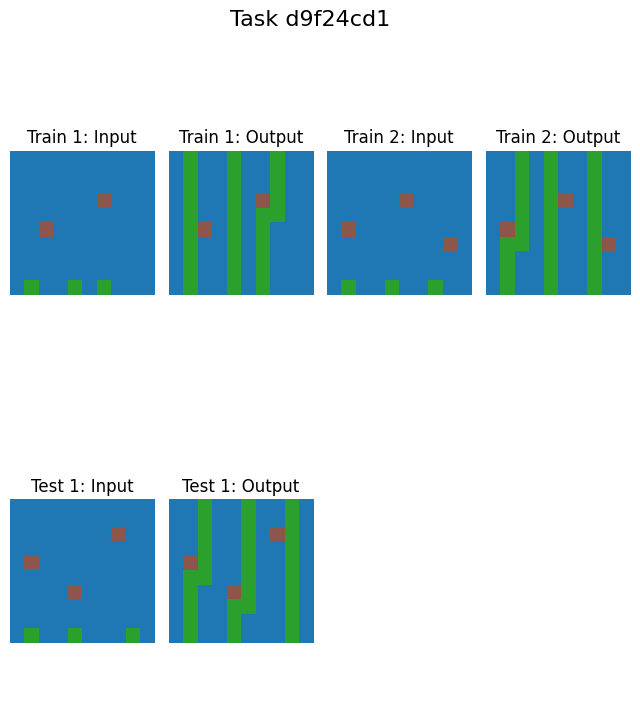

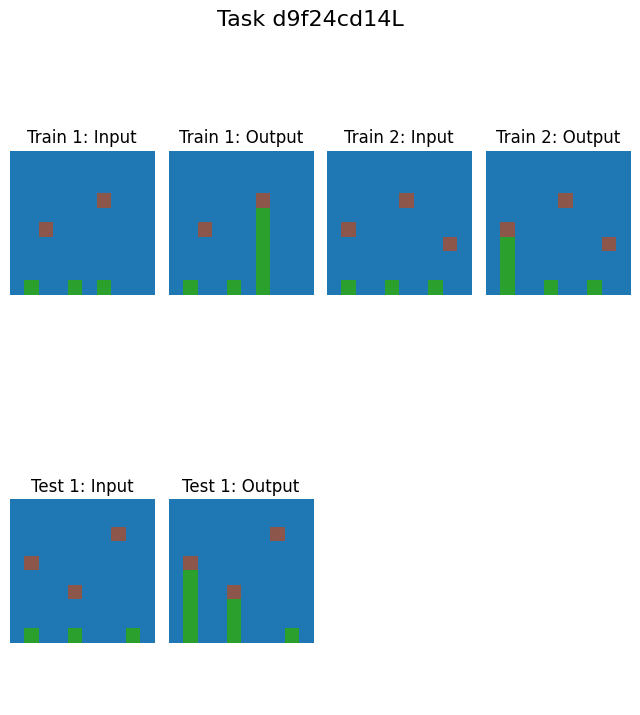

In [1]:
import re 
import os
import copy
from typing import Dict
from alphaarc.task import Task
from alphaarc import PROJECT_FOLDER_PATH
from alphaarc.policy.environment import execute_candidate_program
from pathlib import Path
import json
from pathlib import Path
import json
from queue import Queue
from alphaarc.task import Task, from_dict

from alphaarc.augment.mutate_grid import valid_grid

def find_grid_functions(filename):
    with open(filename, "r") as file:
        contents = file.read()
    pattern = re.compile(
    r'^\s*def\s+(\w+)'           # capture the function name
    r'(?=\s*\([^)]*\)\s*'        # look-ahead to be sure it is followed by …
    r'->\s*Grid\s*:)',           # … “-> Grid:”
    flags=re.MULTILINE | re.DOTALL)
    function_names = re.findall(pattern, contents)
    return function_names




GRID_FUNCTIONS = find_grid_functions(
    filename=os.path.join(PROJECT_FOLDER_PATH, "alphaarc/dsl/dsl.py")
)
STANDALONE_I = re.compile(r'\bI\b')      

def contains_grid_type(line):
    for grid_func in GRID_FUNCTIONS:
        if grid_func in line:
            return True
    return False

def contains_exact_x_arg(code_str, x_arg):
    pattern = rf'\b\w+\s*\([^)]*\b{x_arg}(?!\w)[^)]*\)'
    return bool(re.search(pattern, code_str))

def get_lines_vars(line_array):
    return [line.split("=")[0].strip() for line in line_array]


def check_any_var_used(vars, program_lines): 
    for l in program_lines:
        
        line = l.split("=")[1]

        for var in vars:
            if contains_exact_x_arg(line, var):
                return True

    return False



def check_all_var_used(vars, program_lines):
    
    for var in vars:
        
        found = False
        for l in program_lines:
            line = l.split("=")[1]

            if contains_exact_x_arg(line, var):
                found = True
        
        if not found:
            return False
        
    
    return True



def check_input_used(program_lines):
    for line in program_lines: 
        if bool(STANDALONE_I.search(line)):
            return True
    return False




def convert_line_to_output_line(line): 
    lhs, rhs = line.split('=', 1)          # split once, just at the first '='
    return f"O ={rhs}" 


# may somewhat break with just a single output but can cope with that when we get there (or just not transform those)
def create_left_program_string(program_lines):
    program_lines[-1] = convert_line_to_output_line(program_lines[-1])
    program_string = "\n".join(program_lines)
    return program_string


def rename_lhs_vars(lines):
    
    lhs_to_new: Dict[str, str] = {}
    counter = 1
    for line in lines:
        m = re.match(r'\s*([A-Za-z_]\w*)\s*=', line)
        if m:
            name = m.group(1)
            if name not in lhs_to_new:
                lhs_to_new[name] = f"x{counter}"
                counter += 1

    # Nothing to rename?  Just hand the original back.
    if not lhs_to_new:
        return lines

    # Pass 2 ── swap every whole-word hit with its new name
    pattern = re.compile(r'\b(' + '|'.join(map(re.escape, lhs_to_new)) + r')\b')

    def repl(match):
        return lhs_to_new[match.group(0)]

    return [pattern.sub(repl, line) for line in lines]

def create_right_program_string(program_lines, pruned_variable_name): 
    if len(program_lines) == 1:
        
        if pruned_variable_name != "O":
            result = program_lines[0].split("=")[1].replace(pruned_variable_name, "I")
            program_lines[0] = f"O ={result}"
        return program_lines[0]

    program_lines = program_lines[1:]
    

    for i, line in enumerate(program_lines):

        new_line = line.replace(pruned_variable_name, "I")
        program_lines[i] = new_line
    
    
    
    lines = rename_lhs_vars(program_lines)

    lines[-1] = convert_line_to_output_line( lines[-1])
    
    return "\n".join(lines)
    
    

def create_task_dict(inputs, outputs):
    return {"input": inputs, "output": outputs}



# ok so this basically just maps the input to the output and calls it a day.
def create_left_task(line, line_index, program_lines, task): 
    new_training_targets = []
    new_test_targets = []

    left_program_string = create_left_program_string(program_lines[:line_index + 1])
    

    for inp in [x['input'] for x in task.training_examples]:
        output = execute_candidate_program( left_program_string, inp)
        new_training_targets.append(output)

    for inp in [x['input'] for x in task.test_examples]:
        output = execute_candidate_program( left_program_string, inp)
        new_test_targets.append(output)



    for outputs in new_training_targets + new_test_targets:
        if not valid_grid(outputs):
            return []


    left_training_examples = []
    left_test_examples = []

    for i, inp in enumerate([x['input'] for x in task.training_examples]):
        left_training_examples.append(create_task_dict(inp, new_training_targets[i]))

    for i, inp in enumerate([x['input'] for x in task.test_examples]):
        left_test_examples.append(create_task_dict(inp, new_test_targets[i]))
    

    left_task = Task(left_program_string, left_training_examples, left_test_examples, task.task_key+ str(line_index) + "L", parent_key=task.task_key )
    return [left_task]



def create_right_task(line, line_index, program_lines, task, task_key): 
    new_training_targets = []
    new_test_targets = []
    
    pruned_var = get_lines_vars([line])[0]
    right_program_string = create_right_program_string(program_lines[line_index:], pruned_variable_name=pruned_var)

    for inp in [x['output'] for x in task.training_examples]:
        output = execute_candidate_program( right_program_string, inp)
        new_training_targets.append(output)

    for inp in [x['output'] for x in task.test_examples]:
        output = execute_candidate_program( right_program_string, inp)
        new_test_targets.append(output)



    right_training_example = []
    right_test_example = []


    for i, inp in enumerate([x['output'] for x in task.training_examples]):
        right_training_example.append(create_task_dict(inp, new_training_targets[i]))

    for i, inp in enumerate([x['output'] for x in task.test_examples]):
        right_test_example.append(create_task_dict(inp, new_test_targets[i]))
    
    
    right_task = Task(right_program_string, right_training_example, right_test_example, task_key+ str(line_index) + "R", parent_key=task_key )
    return [right_task]




def left_program_can_be_created(line, line_index, program_lines):
    previous_lines = program_lines[:line_index+1]
    previous_lines_vars = get_lines_vars(previous_lines)[:-1]
    return check_all_var_used(previous_lines_vars, previous_lines) # and not check_any_var_used(previous_lines_vars, future_lines) 
     

def right_program_can_be_created(line, line_index, program_lines):
    previous_lines = program_lines[:line_index]
    future_lines = program_lines[line_index +1:]
    previous_lines_vars = get_lines_vars(previous_lines)
    return (not check_any_var_used(previous_lines_vars, future_lines)) and (not check_input_used(future_lines))



def compress(program_lines: list, task: Task):
    new_tasks = []

    for i, line in enumerate(program_lines):   
            if contains_grid_type(line) and "O" not in line.split("=")[0]:
                if left_program_can_be_created(line, i, program_lines):
                    
                    left_task = create_left_task(line, i, program_lines, task)
                    new_tasks.extend(left_task )
                    if right_program_can_be_created(line, i, program_lines) and len(left_task)> 0:
                        new_tasks.extend(create_right_task(line, i, program_lines, left_task[0], task_key=task.task_key))
                

    return new_tasks

def collate_task_inputs(task: Task): 
    program_inputs = []

    train_inputs = [x['input'] for x in task.training_examples]
    test_input = [x['input'] for x in task.test_examples]
    
    program_inputs.extend(train_inputs)
    program_inputs.extend(test_input)

    return program_inputs


class UniqueTaskQueue:
    def __init__(self):
        self.queue = Queue()
        self.seen_programs = set()

    def put(self, task):
        if task not in self.seen_programs:
            self.queue.put(task)
            self.seen_programs.add(task)

    def get(self):
        return self.queue.get()

    def empty(self):
        return self.queue.empty()


def load_tasks_from_folders(dir_path):
        tasks = []
        file_paths = [os.path.join(dir_path, f) for f in os.listdir(dir_path)]
        new_tasks = [Task.from_json(path, False) for path in file_paths]
        tasks.extend(new_tasks)

        return tasks

def load_tasks_from_files(file_path):
    tasks = [ ]
    with open(file_path) as fp:
        json_object = json.load(fp)
    task_keys = json_object.keys()
    new_tasks = [from_dict(json_object[key], False) for key in task_keys]
    tasks.extend(new_tasks)

    return tasks

def load_train_tasks(dirs, files, ):
    
    tasks = []
    for folder_path in dirs:
         tasks.extend(load_tasks_from_folders(folder_path))
    
    for file_path in files:
        tasks.extend(load_tasks_from_files(file_path))

    return tasks



def main():
    
    tasks =  load_train_tasks(dirs=[ '../data/training'], files=[]) # files=['data/mutated_tasks_train_9600.json', 'data/mutated_tasks_train_19200.json'])


    task_queue = UniqueTaskQueue()              # queue for new tasks
    processed_tasks = []    


    for task in tasks:
        task_queue.put(task)

    while not task_queue.empty():
        task = task_queue.get()
        program_lines = task.program_lines.split("\n")
        compressed_tasks = compress(program_lines, task)
        


        task.display_task()
     
        compressed_tasks[0].display_task()


        return 
        for new_task in compressed_tasks:
            if new_task not in task_queue.seen_programs:
                processed_tasks.append(new_task)
            
            task_queue.put(new_task)

            


    json_objects = [task.to_dict() for task in processed_tasks]
    print(f"created {len(json_objects)} tasks")
    

    

    



main()


# Notebook for Generating New Tasks

This notebook contains the analysis presented in the chapter related to generating new tasks, please run the compress .py file to generate the jsonl file used in this.

In [117]:
from transformers import T5ForConditionalGeneration, AutoTokenizer
from alphaarc.task import Task
import torch
import matplotlib.pyplot as plt
import numpy as np 
import json
import torch, tqdm, pickle
from pathlib import Path
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from transformers import T5ForConditionalGeneration, AutoTokenizer
from alphaarc.task import Task, from_dict
import torch
import matplotlib.pyplot as plt
import numpy as np 
import json
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [118]:
# do some loading.

import json
import random
import os



def load_train_tasks(dirs, files, split_keys_path= '../data/split_keys.json', dev_mode=True):
    

    
    tasks = []
    for folder_path in dirs:
         tasks.extend(load_tasks_from_folders(folder_path))
    
    for file_path in files:
        tasks.extend(load_tasks_from_files(file_path))


    

    random.shuffle(tasks)
    return tasks

def load_tasks_from_folders(dir_path):
        tasks = []
        file_paths = [os.path.join(dir_path, f) for f in os.listdir(dir_path)]
        new_tasks = [Task.from_json(path, False) for path in file_paths]
        tasks.extend(new_tasks)

        return tasks

def load_tasks_from_files(file_path):
    tasks = [ ]
    with open(file_path) as fp:
        json_object = json.load(fp)
    task_keys = json_object.keys()
    new_tasks = [from_dict(json_object[key], False) for key in task_keys]
    tasks.extend(new_tasks)

    return tasks

def load_key_split(split_keys_path): 

    with open(split_keys_path) as fp:
        json_object = json.load(fp)

    return json_object


    


tasks = load_train_tasks(dirs=[ '../data/training'], files=[]) # files=['../data/mutated_tasks_train_9600.json', '../data/mutated_tasks_train_19200.json'])
new_tasks = []
with open("../data/new_tasks.jsonl", "r") as f:
    for line in f:
        new_tasks.append(json.loads(line))


new_tasks = [from_dict(x) for x in new_tasks]


## Number of Duplicate Programs

In [119]:
def compute_n_of_non_duplicate_tasks(new_tasks):
    program_lines = []

    for task in new_tasks:
        program_lines.append( task.program_lines)
    print(f"n of unique programs: {len(set(program_lines))} / {len(program_lines)}")


compute_n_of_non_duplicate_tasks(new_tasks)

n of unique programs: 299 / 366


## Number of Tasks Generated Per Task

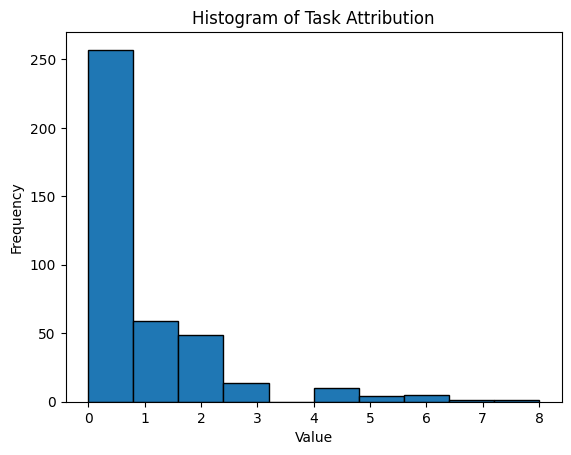

In [120]:
def compute_n_generating_tasks(original_tasks, new_tasks):
    
    save = {}
    for t in original_tasks:
        save[t.task_key] = []




    for t_id in save.keys():

        for new_t in new_tasks:
            if new_t.parent_key == t_id:
                save[t_id].append(new_t) 
    

    data = [len(arr) for arr in save.values()]
    plt.hist(data,edgecolor='black')

    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram of Task Attribution')
    # Set more x-axis ticks
    # Show plot
    plt.show()



        


compute_n_generating_tasks(tasks, new_tasks)

## Histogram of Lengths

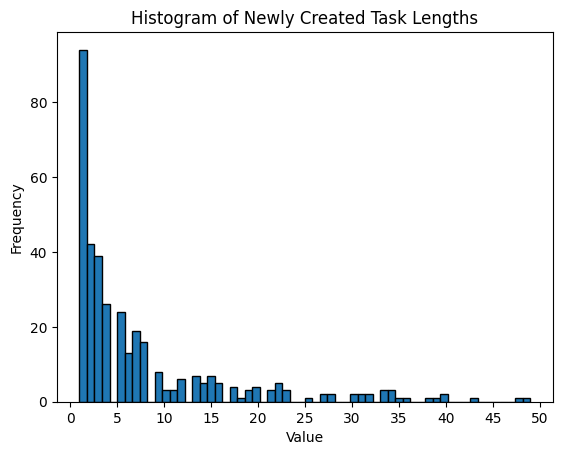

In [121]:
def plot_histogram_of_new_tasks_lengths(new_tasks):
    data = []

    for task in new_tasks:
        data.append( len(task.program_lines.split("\n")))

    plt.hist(data, bins=60, edgecolor='black')

    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram of Newly Created Task Lengths')
    # Set more x-axis ticks
    min_val, max_val = min(data), max(data)
    xticks = np.arange(0, max_val + 5, 5)
    plt.xticks(xticks)
    # Show plot
    plt.show()

plot_histogram_of_new_tasks_lengths(new_tasks)

## Regular Points or Interpoints?

In [122]:
def compute_ratio_of_split_points(tasks, new_tasks):
    save = {}
    for t in tasks:
        save[t.task_key] = []




    for t_id in save.keys():

        for new_t in new_tasks:
            if new_t.parent_key == t_id:
                save[t_id].append(new_t) 
    

    data = [len(arr) for arr in save.values()]

    total_tasks = sum(data)
    print(f"programs created by original tasks {total_tasks} and by intersplit point {len(new_tasks) - total_tasks}")

compute_ratio_of_split_points(tasks, new_tasks)

programs created by original tasks 304 and by intersplit point 62


## Created by Left or Right?

In [123]:
def compute_left_or_right(tasks, new_tasks):

    left_count = 0
    right_count = 0

    for task in new_tasks:

        if "R" in task.task_key:
            right_count +=1
        else:
            left_count +=1
    

    print(f"created by left: {left_count} created by right: {right_count}")


compute_left_or_right(tasks, new_tasks)


created by left: 220 created by right: 146


## Qualative Example

x1 = ofcolor(I, TWO)
x2 = ofcolor(I, FIVE)
x3 = prapply(connect, x1, x2)
x4 = mfilter(x3, vline)
x5 = underfill(I, TWO, x4)
x6 = matcher(numcolors, TWO)
x7 = objects(x5, F, F, T)
x8 = sfilter(x7, x6)
x9 = difference(x7, x8)
x10 = colorfilter(x9, TWO)
x11 = mapply(toindices, x10)
x12 = apply(urcorner, x8)
x13 = shift(x12, UNITY)
x14 = rbind(shoot, UP)
x15 = mapply(x14, x13)
x16 = fill(x5, TWO, x15)
x17 = mapply(vfrontier, x11)
O = fill(x16, TWO, x17)


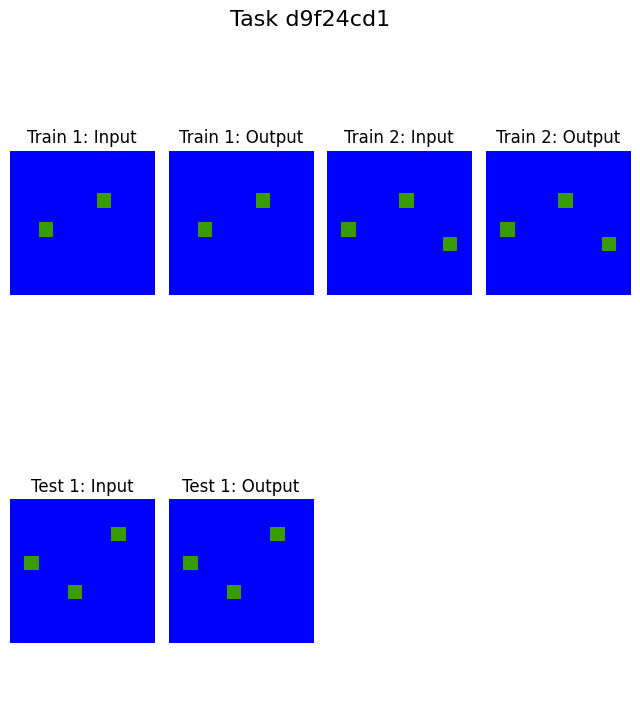

x1 = ofcolor(I, TWO)
x2 = ofcolor(I, FIVE)
x3 = prapply(connect, x1, x2)
x4 = mfilter(x3, vline)
O = underfill(I, TWO, x4)


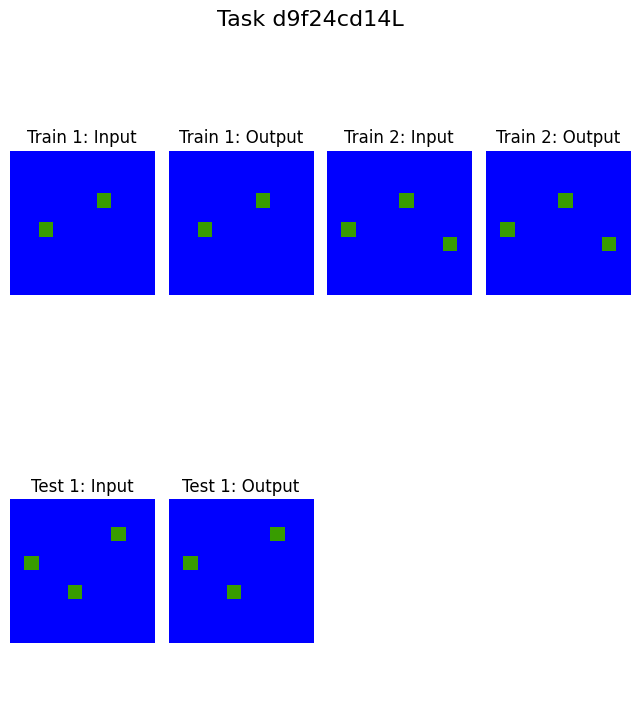

x1 = matcher(numcolors, TWO)
x2 = objects(I, F, F, T)
x3 = sfilter(x2, x1)
x4 = difference(x2, x3)
x5 = colorfilter(x4, TWO)
x6 = mapply(toindices, x5)
x7 = apply(urcorner, x3)
x8 = shift(x7, UNITY)
x9 = rbind(shoot, UP)
x10 = mapply(x9, x8)
x11 = fill(I, TWO, x10)
x12 = mapply(vfrontier, x6)
O = fill(x11, TWO, x12)


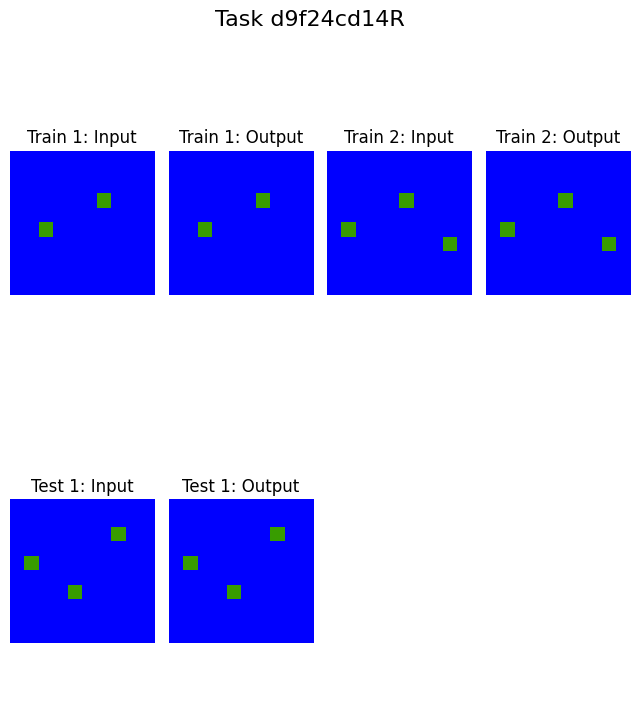

[<alphaarc.task.Task object at 0x7fdf36b73130>, <alphaarc.task.Task object at 0x7fdf36b71a80>]


In [125]:


def display_qualative_example(tasks, new_tasks, chosen_task='d9f24cd1'): 


    chosen_task_obj = None

    for t in tasks:
        if chosen_task in t.task_key:
            chosen_task_obj = t


    print(chosen_task_obj.program_lines)
    chosen_task_obj.display_task()


    created_tasks = []


    for t in new_tasks:

        if t.parent_key == chosen_task_obj.task_key:
            created_tasks.append(t)


    for x in created_tasks:
        print(x.program_lines)
        x.display_task()

    print(created_tasks)



display_qualative_example(tasks, new_tasks)